# Your CGR-SMILES Toolkit: Seamless Reaction Conversions

This notebook demonstrates how to use the `cgr_smiles` library to transform
between **reaction SMILES** and **CGR SMILES**.

We will first explore how the **input data** affects the transformations:
1. Fully mapped & balanced reactions (best case)
2. Unmapped reactions
3. Unbalanced reactions

Then we will look at the **different usage options**:
- Core functions (simple, flexible)
    - `rxn_to_cgr()`
    - `cgr_to_rxn()`
- Wrapper classes (convenient for bulk data)
    - `RxnToCgr()`
    - `CgrToRxn()`
- CLI (file-based workflows)
    - `rxn2cgr`
    - `cgr2rxn`

In [39]:
from rdkit.Chem import Draw, rdChemReactions

from cgr_smiles import RxnToCgr, cgr_to_rxn, rxn_to_cgr
from cgr_smiles.utils import canonicalize

## 1. Transforming Different Types of Reaction Data

### A. Fully Mapped & Balanced Reactions (The Ideal Case)

When your reaction SMILES are already fully atom-mapped and balanced, the transformation is straightforward. If atom mapping is preserved during the process (`keep_atom_mapping=True`), the round-trip conversion from `RXN → CGR → RXN` will yield an **equivalent reaction SMILES string with its original atom mapping**. While the exact string might sometimes differ due to canonicalization, the chemical transformation represented remains identical.

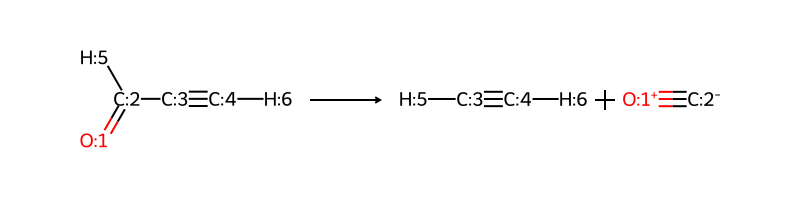

In [51]:
rxn_smiles = "[O:1]=[C:2]([C:3]#[C:4][H:6])[H:5]>>[C:3](#[C:4][H:6])[H:5].[O+:1]#[C-:2]"

# Visualize the reaction
rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles, useSmiles=True)
Draw.ReactionToImage(rxn)

In [52]:
# Convert to CGR SMILES, keeping atom mapping
cgr_smiles = rxn_to_cgr(rxn_smiles, keep_atom_mapping=True)
print(f"CGR SMILES (with mapping):\n\t{cgr_smiles}\n")

# Convert back
rxn_back = cgr_to_rxn(cgr_smiles)
print(f"Back to reaction SMILES:\n\t{rxn_back}")

# Round-trip check
assert canonicalize(rxn_back) == canonicalize(rxn_smiles)

CGR SMILES (with mapping):
	{[O:1]|[O+:1]}{=|#}{[C:2]|[C-:2]}1{-|~}[C:3](#[C:4][H:6]){~|-}[H:5]{-|~}1

Back to reaction SMILES:
	[O:1]=[C:2]([C:3]#[C:4][H:6])[H:5]>>[O+:1]#[C-:2].[C:3](#[C:4][H:6])[H:5]


👉 Note: By default, atom mapping is *not* preserved in the generated CGR SMILES (`keep_atom_mapping=False`). When converting such a CGR SMILES back into a reaction SMILES, atom map numbers will be reassigned. The specific mapping numbers in the resulting reaction SMILES might differ from the original input, but the chemical integrity and atom-to-atom correspondence (the mapping relationships) are maintained.

In [54]:
rxn_smiles = "[O:10]=[C:20]([C:3]#[C:4][H:6])[H:5]>>[C:3](#[C:4][H:6])[H:5].[O+:10]#[C-:20]"
cgr_smiles = rxn_to_cgr(rxn_smiles)
print(f"CGR SMILES (without mapping):\n\t{cgr_smiles}\n")

rxn_back = cgr_to_rxn(cgr_smiles)
print(f"RXN SMILES (with different mapping numbers):\n\t{rxn_back}\n")

[2025-09-02 14:21] WARNING: Failed to process CGR-SMILES '{[O]|[O+]}{=|#}{[C]|[C-]}1{-|~}[C](#[C][H]){~|-}[H]{-|~}1'. Error: 1002. Returning empty string.


CGR SMILES (without mapping):
	{[O]|[O+]}{=|#}{[C]|[C-]}1{-|~}[C](#[C][H]){~|-}[H]{-|~}1

RXN SMILES (with different mapping numbers):
	



### B. Unmapped Reactions: How to Assign Atom Maps

When your input reaction SMILES lacks atom mapping, the `rxn_to_cgr` function requires a `mapping_method` to internally assign these maps before a CGR can be constructed. We offer two primary options:

1.  **`'graph_overlay'`**: An RDKit-based method leveraging maximum common substructure analysis to identify atom correspondences between reactants and products.
2.  **`'rxnmapper'`**: Utilizes the external RXNMapper tool, which employs a neural network for highly accurate atom mapping. (Requires the `rxnmapper` Python package to be installed separately.)

👉 **Tip**: While you can specify `mapping_method` with the core functions, processing many unmapped reactions is significantly more efficient using the **wrapper classes**, which are designed to optimize batch mapping.

In [55]:
# Example: Unmapped reaction SMILES
rxn_smiles_unmapped = "CCO>>CC=O"

# Option 1: Using 'rxnmapper' (requires rxnmapper to be installed)
print("--- Using 'rxnmapper' ---")
cgr_rxnmapper = rxn_to_cgr(rxn_smiles_unmapped, mapping_method="rxnmapper", keep_atom_mapping=False)
print("CGR SMILES (via RXNMapper):", cgr_rxnmapper)

rxn_back_rxnmapper = cgr_to_rxn(cgr_rxnmapper)
print("Back to reaction SMILES (new maps assigned):", rxn_back_rxnmapper)
print("Round-trip string equal (RXNMapper)?", rxn_back_rxnmapper == rxn_smiles_unmapped)

# Option 2: Using 'graph_overlay'
print("\n--- Using 'graph_overlay' ---")
cgr_graph_overlay = rxn_to_cgr(rxn_smiles_unmapped, mapping_method="graph_overlay", keep_atom_mapping=False)
print("CGR SMILES (via Graph Overlay):", cgr_graph_overlay)

rxn_back_graph_overlay = cgr_to_rxn(cgr_graph_overlay)
print("Back to reaction SMILES (new maps assigned):", rxn_back_graph_overlay)
print("Round-trip string equal (Graph Overlay)?", rxn_back_graph_overlay == rxn_smiles_unmapped)

--- Using 'rxnmapper' ---


TypeError: rxn_to_cgr() got an unexpected keyword argument 'mapping_method'

👉 **Note**: When using `mapping_method='rxnmapper'` for a *single* reaction via the core function, we observe a warning. This is a reminder that for optimal performance and efficiency, especially when handling batches of unmapped reactions, the dedicated **wrapper classes** are the preferred choice.

### C. Handling Unbalanced Reactions

CGR representations intrinsically describe a chemically balanced transformation. If your input reaction SMILES is unbalanced, the user must specify `balance=True` in the function call to enable balancing. After conversion, when using `cgr_to_rxn` to get the reaction SMILES back, it will be in its chemically balanced form.

In [56]:
# Example: Unbalanced reaction SMILES
rxn_unbalanced = "CCO>>CC=O.O"

# Convert, implicitly balancing
cgr_unbalanced = rxn_to_cgr(
    rxn_unbalanced, mapping_method="graph_overlay", keep_atom_mapping=False
)  # Or 'rxnmapper'
print("CGR (unbalanced input):", cgr_unbalanced)

# Convert back, now balanced
rxn_back_unbalanced = cgr_to_rxn(cgr_unbalanced)
print("Back to reaction SMILES (now balanced):", rxn_back_unbalanced)

TypeError: rxn_to_cgr() got an unexpected keyword argument 'mapping_method'

## 2. Streamlining Your Workflow: Different Usage Options

### A. Core Functions (`rxn_to_cgr`, `cgr_to_rxn`)

As demonstrated in the previous sections, the core functions provide direct access to the `RXN → CGR` and `CGR → RXN` logic. They are best suited for:
- Quick experiments with single reactions.
- Scenarios where you need fine-grained control over mapping parameters.
- Integration into custom scripts.


### B. Wrapper Classes (`RxnToCgr`, `CgrToRxn`)

These wrapper classes provide a convenient and efficient callable interface, particularly beneficial for:
- **Bulk data processing**: Lists, pandas Series, or DataFrames.
- **Streamlined mapping**: When dealing with multiple unmapped reactions, the wrapper efficiently handles the mapping process (e.g., calling RXNMapper once for a batch), significantly improving performance compared to individual function calls.

In [57]:
import pandas as pd

# Example list of reactions
# [TODO]: load from a csv file
rxn_list = [
    "CCO>>CC=O",  # Unmapped
    "N.C>>NC",  # Unmapped
    "[CH3:1][OH:2]>>[CH2:1]=[O:2]",  # Mapped
]

# Using the RxnToCgrTransform wrapper for a list
transform_to_cgr = RxnToCgr(mapping_method="rxnmapper", keep_atom_mapping=False)
cgr_results = transform_to_cgr(rxn_list)
print("CGRs from list:", cgr_results)

# Using the wrapper for a pandas DataFrame
df_data = pd.DataFrame({"reactions": rxn_list})
transform_to_cgr_df = RxnToCgr(mapping_method="graph_overlay", rxn_col="reactions", keep_atom_mapping=False)
df_data["cgr_smiles"] = transform_to_cgr_df(df_data)
print("\nDataFrame with CGRs:\n", df_data)

TypeError: RxnToCgr.__init__() got an unexpected keyword argument 'mapping_method'

### C. Command Line Interface (`rxn2cgr`, `cgr2rxn`)

For file-based workflows or for users who prefer not to write Python code, the Command-Line Interface (CLI) is ideal.

In [50]:
# Example usage of the CLI (run these commands in your terminal, not in this notebook cell)

# Convert a CSV of reaction SMILES to CGR SMILES
# rxn2cgr input.csv -o output_cgr.csv --rxn-col reactions --cgr-col cgr_smiles --mapping-method rxnmapper --keep-atom-mapping

# Convert a CSV of CGR SMILES back to reaction SMILES
# cgr2rxn output_cgr.csv -o output_rxn.csv --cgr-col cgr_smiles --rxn-col rxn_back

And that's a wrap! You've now successfully navigated the `cgr_smiles` library for transforming reaction data. For complete API references and advanced topics, be sure to check out the [official documentation](https://your-docs-link-here).

# Your CGR-SMILES Toolkit: Seamless Reaction Conversions

This notebook demonstrates how to use the `cgr_smiles` library to transform
between **reaction SMILES** and **CGR SMILES**.

We will first explore how the **input data** affects the transformations:
1. Fully mapped & balanced reactions (best case)
2. Unmapped reactions
3. Unbalanced reactions

Then we will look at the **different usage options**:
- Core functions (simple, flexible)
    - `rxn_to_cgr()`
    - `cgr_to_rxn()`
- Wrapper classes (convenient for bulk data)
    - `RxnToCgr()`
    - `CgrToRxn()`
- CLI (file-based workflows)
    - `rxn2cgr`
    - `cgr2rxn`

In [39]:
from rdkit.Chem import Draw, rdChemReactions

from cgr_smiles import RxnToCgr, cgr_to_rxn, rxn_to_cgr
from cgr_smiles.utils import canonicalize

## 1. Transforming Different Types of Reaction Data

### A. Fully Mapped & Balanced Reactions (The Ideal Case)

When your reaction SMILES are already fully atom-mapped and balanced, the transformation is straightforward. If atom mapping is preserved during the process (`keep_atom_mapping=True`), the round-trip conversion from `RXN → CGR → RXN` will yield an **equivalent reaction SMILES string with its original atom mapping**. While the exact string might sometimes differ due to canonicalization, the chemical transformation represented remains identical.

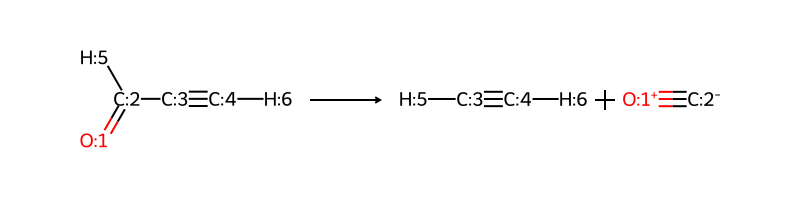

In [51]:
rxn_smiles = "[O:1]=[C:2]([C:3]#[C:4][H:6])[H:5]>>[C:3](#[C:4][H:6])[H:5].[O+:1]#[C-:2]"

# Visualize the reaction
rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles, useSmiles=True)
Draw.ReactionToImage(rxn)

In [52]:
# Convert to CGR SMILES, keeping atom mapping
cgr_smiles = rxn_to_cgr(rxn_smiles, keep_atom_mapping=True)
print(f"CGR SMILES (with mapping):\n\t{cgr_smiles}\n")

# Convert back
rxn_back = cgr_to_rxn(cgr_smiles)
print(f"Back to reaction SMILES:\n\t{rxn_back}")

# Round-trip check
assert canonicalize(rxn_back) == canonicalize(rxn_smiles)

CGR SMILES (with mapping):
	{[O:1]|[O+:1]}{=|#}{[C:2]|[C-:2]}1{-|~}[C:3](#[C:4][H:6]){~|-}[H:5]{-|~}1

Back to reaction SMILES:
	[O:1]=[C:2]([C:3]#[C:4][H:6])[H:5]>>[O+:1]#[C-:2].[C:3](#[C:4][H:6])[H:5]


👉 Note: By default, atom mapping is *not* preserved in the generated CGR SMILES (`keep_atom_mapping=False`). When converting such a CGR SMILES back into a reaction SMILES, atom map numbers will be reassigned. The specific mapping numbers in the resulting reaction SMILES might differ from the original input, but the chemical integrity and atom-to-atom correspondence (the mapping relationships) are maintained.

In [54]:
rxn_smiles = "[O:10]=[C:20]([C:3]#[C:4][H:6])[H:5]>>[C:3](#[C:4][H:6])[H:5].[O+:10]#[C-:20]"
cgr_smiles = rxn_to_cgr(rxn_smiles)
print(f"CGR SMILES (without mapping):\n\t{cgr_smiles}\n")

rxn_back = cgr_to_rxn(cgr_smiles)
print(f"RXN SMILES (with different mapping numbers):\n\t{rxn_back}\n")

[2025-09-02 14:21] WARNING: Failed to process CGR-SMILES '{[O]|[O+]}{=|#}{[C]|[C-]}1{-|~}[C](#[C][H]){~|-}[H]{-|~}1'. Error: 1002. Returning empty string.


CGR SMILES (without mapping):
	{[O]|[O+]}{=|#}{[C]|[C-]}1{-|~}[C](#[C][H]){~|-}[H]{-|~}1

RXN SMILES (with different mapping numbers):
	



### B. Unmapped Reactions: How to Assign Atom Maps

When your input reaction SMILES lacks atom mapping, the `rxn_to_cgr` function requires a `mapping_method` to internally assign these maps before a CGR can be constructed. We offer two primary options:

1.  **`'graph_overlay'`**: An RDKit-based method leveraging maximum common substructure analysis to identify atom correspondences between reactants and products.
2.  **`'rxnmapper'`**: Utilizes the external RXNMapper tool, which employs a neural network for highly accurate atom mapping. (Requires the `rxnmapper` Python package to be installed separately.)

👉 **Tip**: While you can specify `mapping_method` with the core functions, processing many unmapped reactions is significantly more efficient using the **wrapper classes**, which are designed to optimize batch mapping.

In [55]:
# Example: Unmapped reaction SMILES
rxn_smiles_unmapped = "CCO>>CC=O"

# Option 1: Using 'rxnmapper' (requires rxnmapper to be installed)
print("--- Using 'rxnmapper' ---")
cgr_rxnmapper = rxn_to_cgr(rxn_smiles_unmapped, mapping_method="rxnmapper", keep_atom_mapping=False)
print("CGR SMILES (via RXNMapper):", cgr_rxnmapper)

rxn_back_rxnmapper = cgr_to_rxn(cgr_rxnmapper)
print("Back to reaction SMILES (new maps assigned):", rxn_back_rxnmapper)
print("Round-trip string equal (RXNMapper)?", rxn_back_rxnmapper == rxn_smiles_unmapped)

# Option 2: Using 'graph_overlay'
print("\n--- Using 'graph_overlay' ---")
cgr_graph_overlay = rxn_to_cgr(rxn_smiles_unmapped, mapping_method="graph_overlay", keep_atom_mapping=False)
print("CGR SMILES (via Graph Overlay):", cgr_graph_overlay)

rxn_back_graph_overlay = cgr_to_rxn(cgr_graph_overlay)
print("Back to reaction SMILES (new maps assigned):", rxn_back_graph_overlay)
print("Round-trip string equal (Graph Overlay)?", rxn_back_graph_overlay == rxn_smiles_unmapped)

--- Using 'rxnmapper' ---


TypeError: rxn_to_cgr() got an unexpected keyword argument 'mapping_method'

👉 **Note**: When using `mapping_method='rxnmapper'` for a *single* reaction via the core function, we observe a warning. This is a reminder that for optimal performance and efficiency, especially when handling batches of unmapped reactions, the dedicated **wrapper classes** are the preferred choice.

### C. Handling Unbalanced Reactions

CGR representations intrinsically describe a chemically balanced transformation. If your input reaction SMILES is unbalanced, the user must specify `balance=True` in the function call to enable balancing. After conversion, when using `cgr_to_rxn` to get the reaction SMILES back, it will be in its chemically balanced form.

In [56]:
# Example: Unbalanced reaction SMILES
rxn_unbalanced = "CCO>>CC=O.O"

# Convert, implicitly balancing
cgr_unbalanced = rxn_to_cgr(
    rxn_unbalanced, mapping_method="graph_overlay", keep_atom_mapping=False
)  # Or 'rxnmapper'
print("CGR (unbalanced input):", cgr_unbalanced)

# Convert back, now balanced
rxn_back_unbalanced = cgr_to_rxn(cgr_unbalanced)
print("Back to reaction SMILES (now balanced):", rxn_back_unbalanced)

TypeError: rxn_to_cgr() got an unexpected keyword argument 'mapping_method'

## 2. Streamlining Your Workflow: Different Usage Options

### A. Core Functions (`rxn_to_cgr`, `cgr_to_rxn`)

As demonstrated in the previous sections, the core functions provide direct access to the `RXN → CGR` and `CGR → RXN` logic. They are best suited for:
- Quick experiments with single reactions.
- Scenarios where you need fine-grained control over mapping parameters.
- Integration into custom scripts.


### B. Wrapper Classes (`RxnToCgr`, `CgrToRxn`)

These wrapper classes provide a convenient and efficient callable interface, particularly beneficial for:
- **Bulk data processing**: Lists, pandas Series, or DataFrames.
- **Streamlined mapping**: When dealing with multiple unmapped reactions, the wrapper efficiently handles the mapping process (e.g., calling RXNMapper once for a batch), significantly improving performance compared to individual function calls.

In [57]:
import pandas as pd

# Example list of reactions
# [TODO]: load from a csv file
rxn_list = [
    "CCO>>CC=O",  # Unmapped
    "N.C>>NC",  # Unmapped
    "[CH3:1][OH:2]>>[CH2:1]=[O:2]",  # Mapped
]

# Using the RxnToCgrTransform wrapper for a list
transform_to_cgr = RxnToCgr(mapping_method="rxnmapper", keep_atom_mapping=False)
cgr_results = transform_to_cgr(rxn_list)
print("CGRs from list:", cgr_results)

# Using the wrapper for a pandas DataFrame
df_data = pd.DataFrame({"reactions": rxn_list})
transform_to_cgr_df = RxnToCgr(mapping_method="graph_overlay", rxn_col="reactions", keep_atom_mapping=False)
df_data["cgr_smiles"] = transform_to_cgr_df(df_data)
print("\nDataFrame with CGRs:\n", df_data)

TypeError: RxnToCgr.__init__() got an unexpected keyword argument 'mapping_method'

### C. Command Line Interface (`rxn2cgr`, `cgr2rxn`)

For file-based workflows or for users who prefer not to write Python code, the Command-Line Interface (CLI) is ideal.

In [50]:
# Example usage of the CLI (run these commands in your terminal, not in this notebook cell)

# Convert a CSV of reaction SMILES to CGR SMILES
# rxn2cgr input.csv -o output_cgr.csv --rxn-col reactions --cgr-col cgr_smiles --mapping-method rxnmapper --keep-atom-mapping

# Convert a CSV of CGR SMILES back to reaction SMILES
# cgr2rxn output_cgr.csv -o output_rxn.csv --cgr-col cgr_smiles --rxn-col rxn_back

And that's a wrap! You've now successfully navigated the `cgr_smiles` library for transforming reaction data. For complete API references and advanced topics, be sure to check out the [official documentation](https://your-docs-link-here).